In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
df=pd.read_csv("Zomato data .csv")
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [85]:
df.shape

(148, 7)

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


**1.What type of restaurant do the majority of customers order from?**

<Axes: xlabel='listed_in(type)', ylabel='count'>

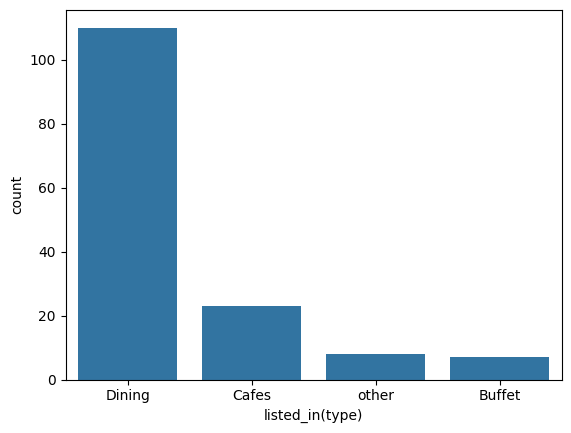

In [87]:
ques1=df.value_counts("listed_in(type)")
sns.barplot(ques1)

**2.How many votes has each type of restaurant received from customers ?**

listed_in(type)
Buffet     3028
Cafes      6434
Dining    20363
other      9367
Name: votes, dtype: int64


<Axes: xlabel='listed_in(type)', ylabel='votes'>

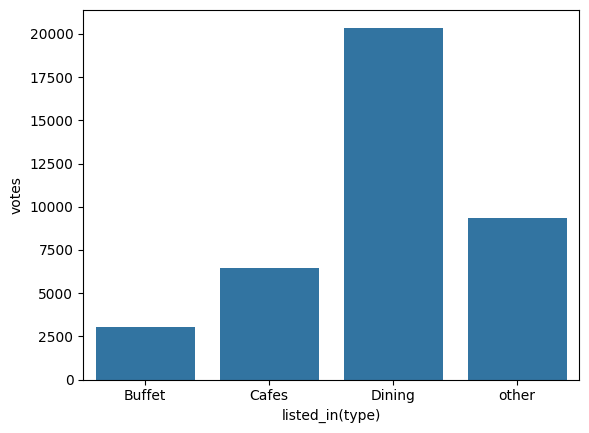

In [95]:
votes = df.groupby('listed_in(type)')['votes'].sum()
print(votes)
sns.barplot(votes)

**3.What are the ratings that the majority of restaurants have received?**

In [89]:
def rat(value):
  val=value.split('/')
  val=val[0]
  return float(val)
df['rate']=df['rate'].apply(rat)
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


The majority of ratings fall between 3.6 and 4.1 out of 5.


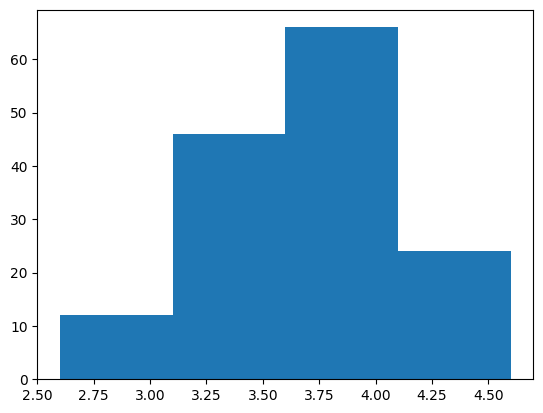

In [90]:
plt.hist(df['rate'],bins=4)
print("The majority of ratings fall between 3.6 and 4.1 out of 5.")

**4. Zomato has observed that most couples order most of their food online. What is their average spending on each order?**

In [91]:
online=df[df['online_order']=='Yes']

q4=online['approx_cost(for two people)'].mean()
print(f"The Average costing is {q4.round()}")

The Average costing is 510.0


**5. Which mode (online or offline) has received the maximum rating?**

Text(0.5, 1.0, 'RATING')

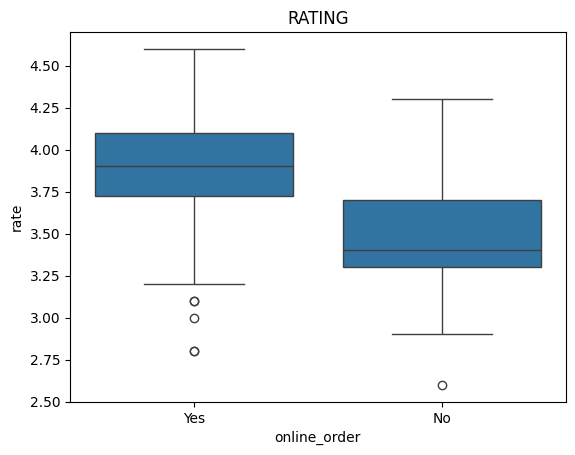

In [92]:
sns.boxplot(x='online_order',y='rate',data=df).set_title("RATING")

**6.Which type of restaurant received more offline orders, so that Zomato can provide those customers with some good offers?**

Text(0.5, 1.0, 'Offline Restaurant Order')

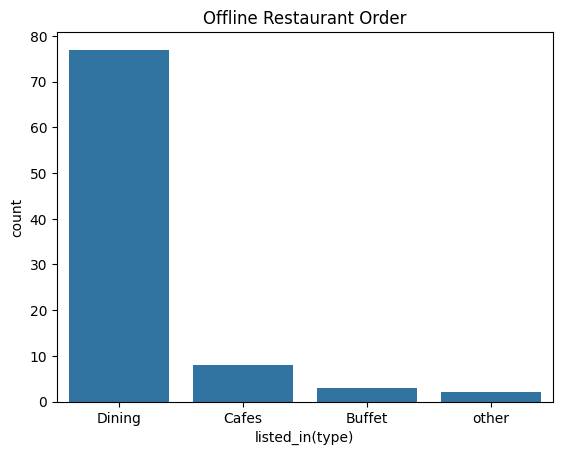

In [93]:
order=df[df['online_order']=='No']
q6=order.value_counts("listed_in(type)")
sns.barplot(q6).set_title('Offline Restaurant Order')